# 01-06 - Coordinate Reference Systems

In 01-03 we typed `to_crs("EPSG:26918")` and promised an explanation. Here it is, and it is the most important extension notebook in this folder.

The Earth is round and our screens are flat, so every map is a compromise, and a coordinate reference system is the specific compromise somebody chose. We look at what a degree actually is, why a degree of longitude in Princeton is shorter than a degree of latitude, what those five digit numbers mean, and what `to_crs` really does to your data.

We finish by measuring the same walk four different ways and getting four different answers, only one of which we would put in a report.

Forty minutes.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

## A degree is an angle, not a length

Latitude and longitude are angles measured from the centre of the Earth. That is the sentence everything else follows from.

Because lines of latitude are parallel circles, a degree of latitude is very nearly the same distance everywhere, about 111 kilometres.

Lines of longitude are not parallel. They all meet at the poles, so the distance covered by a degree of longitude depends on how far north you are. At the equator it is also about 111 kilometres. At the poles it is zero. In between it shrinks by the cosine of your latitude:

In [2]:
for latitude in (0, 40.35, 60, 80):
    width = 111.32 * np.cos(np.radians(latitude))
    print(f"at latitude {latitude:5}: one degree of longitude is about {width:6.1f} km")

at latitude     0: one degree of longitude is about  111.3 km
at latitude 40.35: one degree of longitude is about   84.8 km
at latitude    60: one degree of longitude is about   55.7 km
at latitude    80: one degree of longitude is about   19.3 km


At Princeton's latitude of about 40.35, a degree of longitude is around 85 kilometres, i.e. roughly three quarters as wide as a degree of latitude is tall.

This is why every map of Princeton we drew with degree axes looked slightly squashed, and it is why you can never treat a difference in degrees as a distance.

## Geographic and projected

There are two families of coordinate system, and the difference is exactly the one above.

A **geographic** system stores angles. `EPSG:4326`, the one your phone and OpenStreetMap use, is geographic: its numbers are degrees, and distances and areas computed from it directly are meaningless.

A **projected** system stores positions on a flat surface, in metres or feet, having already made the compromise of flattening the Earth. Every projected system is accurate for some part of the world and wrong elsewhere, which is why there are thousands of them.

`EPSG` is simply the catalogue that numbers them. The number is a lookup, not a formula, and https://epsg.io will tell you what any of them is.

Four you will meet in this course:

- `EPSG:4326`, degrees, the whole world, what data arrives in.
- `EPSG:26918`, metres, designed for this strip of North America, what we measure in.
- `EPSG:3857`, metres, the whole world, what web maps draw in.
- `EPSG:3424`, feet, New Jersey's own official system.

Note that the last three are all projected and all measured in real units, and they will still give you three different answers to the same question.

## What to_crs actually does

Let us be precise, because the name suggests something more dramatic than what happens.

In [3]:
landmarks = pd.read_csv("data/landmarks.csv")
places = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["lon"], landmarks["lat"]),
    crs="EPSG:4326",
)

nassau_degrees = places[places["id"] == "nassau_hall"]
nassau_metres = nassau_degrees.to_crs("EPSG:26918")

print("in EPSG:4326 ", nassau_degrees.geometry.iloc[0])
print("in EPSG:26918", nassau_metres.geometry.iloc[0])

in EPSG:4326  POINT (-74.65927 40.34877)
in EPSG:26918 POINT (528936.1262007706 4466524.152095945)


The same building, described twice. One says about -74.659 and 40.349; the other says about 528,000 and 4,466,000.

**`to_crs` does not move anything.** Nassau Hall is still Nassau Hall. It re-expresses the same place in a different set of numbers, the way you might give the same temperature in Celsius or Fahrenheit.

Note also that `to_crs` returns a new object and leaves the original untouched. Forgetting that, and expecting a table to have changed after calling `to_crs` on it without storing the result, is a genuinely common bug.

## The same walk, measured four ways

Now the demonstration this notebook exists for. Nassau Hall to the Dinky station is a walk you can take in about seven minutes. Let us measure it in all four systems:

In [4]:
def distance_between(a, b, crs):
    points = places.to_crs(crs)
    first = points[points["id"] == a].geometry.iloc[0]
    second = points[points["id"] == b].geometry.iloc[0]
    return first.distance(second)

for crs, unit in [("EPSG:4326", "degrees"), ("EPSG:26918", "metres"),
                  ("EPSG:3857", "metres"), ("EPSG:3424", "feet")]:
    print(f"{crs:12} {distance_between('nassau_hall', 'dinky', crs):10.2f} {unit}")

EPSG:4326          0.01 degrees
EPSG:26918       571.97 metres
EPSG:3857        752.65 metres
EPSG:3424       1877.10 feet


Four numbers for one walk.

**0.0052 degrees** is not a distance at all. It is an angle, and treating it as a length is the mistake that produced a circle larger than the planet in 01-04.

**571.97 metres** is the right answer. `EPSG:26918` is designed for this strip of longitude and is accurate here to a few centimetres.

**1877.10 feet** is the same right answer in different units, and 1877.10 feet is 572.14 metres, agreeing to within a few centimetres.

**752.65 metres** is where it gets interesting. That is `EPSG:3857`, it is measured in metres, and it is wrong by 180 metres on a walk of less than six hundred.

## Why Web Mercator is wrong, and by exactly how much

`EPSG:3857` is the system every web map draws in, including the background of the interactive maps in 01-02. It is enormously useful for drawing and dangerous for measuring, because it stretches everything away from the equator.

The stretch factor is one over the cosine of the latitude, i.e. the same cosine from the top of this notebook:

In [5]:
predicted = 1 / np.cos(np.radians(40.35))
observed = distance_between("nassau_hall", "dinky", "EPSG:3857") / distance_between("nassau_hall", "dinky", "EPSG:26918")

print(f"predicted stretch at latitude 40.35: {predicted:.3f}")
print(f"observed stretch:                    {observed:.3f}")
print(f"that is {(observed - 1) * 100:.1f} percent too long")

predicted stretch at latitude 40.35: 1.312
observed stretch:                    1.316
that is 31.6 percent too long


Predicted 1.312, observed 1.316, i.e. about 31 percent too long, and the theory explains the observation almost exactly.

This is the failure to take seriously, because `EPSG:3857` passes every naive check. It is projected, it is measured in metres, and it is the most common projected system in the world. A buffer of 400 in it is a real circle of about 305 metres on the ground, and nothing anywhere will tell you.

## The same thing happens to areas

Distances stretch, so areas stretch by the square:

In [6]:
boundary = gpd.read_file("data/princeton_boundary.geojson")

for crs in ["EPSG:4326", "EPSG:26918", "EPSG:3857", "EPSG:3424"]:
    area = boundary.to_crs(crs).geometry.area.iloc[0] / 1e6
    print(f"{crs:12} {area:10.2f}")

EPSG:4326          0.00
EPSG:26918        47.66
EPSG:3857         82.23
EPSG:3424        513.29


/var/folders/yk/vz7vdkds0ld4lh886p4v3lbh0000gn/T/ipykernel_81480/4100073592.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = boundary.to_crs(crs).geometry.area.iloc[0] / 1e6


Read those four numbers, and note that geopandas warned us about the first one.

**0.00** in degrees, which is not zero square kilometres but a meaningless quantity in squared degrees, rounded away. Note that this is one of the very few places geopandas will actually warn you, and it is worth reading warnings rather than filtering them out.

**47.66** in `EPSG:26918`, the correct answer in square kilometres.

**82.23** in Web Mercator, i.e. 1.312 squared times too large, which is a town three quarters bigger than it is.

**513.29** in New Jersey's own system, which is not an error of projection at all but of units: that is square feet divided by a million. This is the number an AI agent reported as Princeton's area during the preparation of this precept.

## Choosing a system without looking it up

You will not always know which system is right for a place. Geopandas will read the bounds of your data and tell you:

In [7]:
print(boundary.estimate_utm_crs())

EPSG:32618


`EPSG:32618`.

Note that this is not the `EPSG:26918` we have been using. Both are UTM zone 18 north, i.e. the same strip of the world measured in metres, and they differ only in the reference model of the Earth's shape, called the **datum**. `26918` uses the North American datum, `32618` uses the global WGS84 one.

For our purposes either is right, and the difference is under a metre. It matters when you combine data from different sources, which is a large part of why professional GIS work is fiddly. What it means for you is that seeing a different number than a classmate is not necessarily a mistake, and saying which one you used is the professional habit.

Here is how much the choice actually costs. The impostor boundary from 01-03 lives in West Virginia, which is in a different UTM zone, so measuring it in ours is slightly wrong:

In [8]:
mystery = gpd.read_file("data/mystery_boundary.geojson")

print(f"in our zone, EPSG:26918:      {mystery.to_crs('EPSG:26918').geometry.area.iloc[0] / 1e6:.3f} km2")
print(f"in its own zone, EPSG:32617:  {mystery.to_crs('EPSG:32617').geometry.area.iloc[0] / 1e6:.3f} km2")

in our zone, EPSG:26918:      7.957 km2
in its own zone, EPSG:32617:  7.900 km2


7.957 against 7.900, i.e. an error of about 0.7 percent from using the neighbouring zone.

That is small, and it is the point. A wrong system can be off by 31 percent or by 0.7 percent, and only one of those is visible. The defence is not to be clever, it is to say which system you used and why.

## Seeing the difference

Finally, the same boundary drawn twice, once in degrees and once in metres, each with equal spacing on both axes:

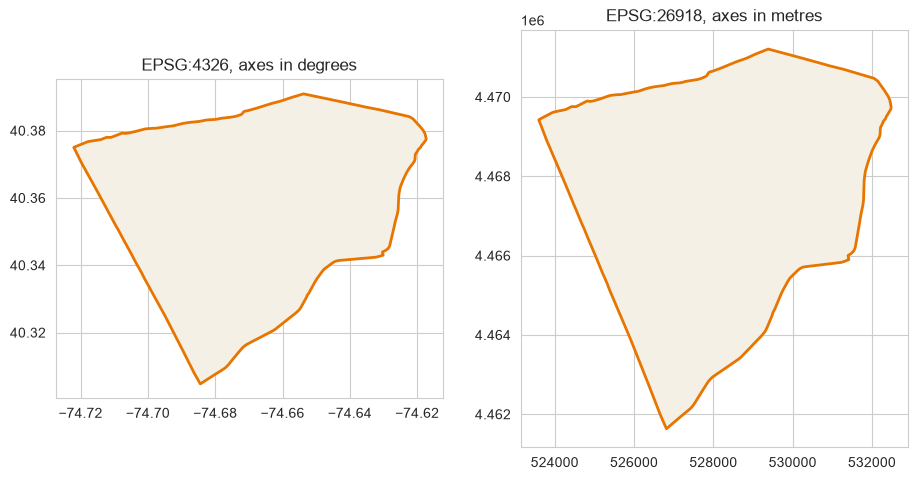

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for axis, crs, label in zip(axes, ["EPSG:4326", "EPSG:26918"], ["degrees", "metres"]):
    boundary.to_crs(crs).plot(ax=axis, color="#f5f0e6", edgecolor="#e77500", linewidth=2)
    axis.set_aspect("equal")
    axis.set_title(f"{crs}, axes in {label}")

The left panel is taller and narrower than the right. Same town, same data, same equal axis spacing, and a visibly different shape.

The right one is correct. The left one is stretched vertically because it is treating a degree of longitude and a degree of latitude as the same size when at this latitude one is about three quarters of the other.

Every map you saw in 01-02 was the left-hand one. Nothing was wrong with them for finding a restaurant, and all of them would have been wrong for measuring anything.

## Check your understanding

1. Why does `.area` on `EPSG:4326` data return 0.00 for our boundary rather than raising an error?
2. Your friend's town is in Oregon. Would `EPSG:26918` be right for them, and how would you find out what is?
3. A colleague sends a map with a 500 metre buffer computed in `EPSG:3857` at latitude 60. Is the real radius larger or smaller than 500 metres, and roughly by how much?
4. `estimate_utm_crs()` gives you 32618 where a classmate used 26918. Is one of you wrong?

## Where we are

You can say what a coordinate reference system is, why degrees are not distances, what `to_crs` does, and why the most common projected system in the world is the wrong one to measure in.

That is the single most transferable thing in this folder. It applies to every spatial dataset you will ever open, in any software.

In 01-07 we look properly at the buffer we have been using, and at the distinction that decides more analyses than any other.

## Further resources

Nothing in this course requires anything below.

Look up any EPSG number at https://epsg.io, which gives its units, its area of use and its definition. Compare https://epsg.io/26918 with https://epsg.io/3857 and read the "Area of use" line on each. The PROJ documentation explains what happens mathematically during a reprojection: https://proj.org/en/stable/usage/projections.html.

For why so many systems exist, the Wikipedia article on map projections is unusually good, and its animated comparisons make the compromise visible: https://en.wikipedia.org/wiki/Map_projection.